#### This Python code implements a Logistic Regression classifier using the Social Network Ads dataset to predict whether a user will purchase a product or not based on their Gender, Age, and Estimated Salary.

In [47]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # MATLAB-like way of plotting
# sklearn package for machine learning in python:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from mpl_toolkits.mplot3d import Axes3D

In [25]:
# read data (make sure .csv in folder)
df = pd.read_csv('social_network_ads.csv')
print(df.head(),'\n') # print first 5 rows of data

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0 



In [26]:
# remove the redundant column
df = df.drop(['User ID'], axis = 1)

In [28]:
# encode the labels (strings) with a numerical value
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 2})

 - Loads the dataset from a CSV file.

 - Drops the User ID column (it's not useful for prediction).

 - Converts the Gender column from string to numeric using .map().

####  Purpose: Make the data machine-readable for logistic regression.

In [29]:
# another way to encode labels
# (make sure you comment out the previous way)
#df.iloc[:,0] = LabelEncoder().fit_transform(df.iloc[:,0])

In [30]:
print(df.head(), '\n')

   Gender  Age  EstimatedSalary  Purchased
0       1   19            19000          0
1       1   35            20000          0
2       2   26            43000          0
3       2   27            57000          0
4       1   19            76000          0 



In [38]:
X = df.iloc[:, [0,1,2]].values # Features: Gender, Age, EstimatedSalary
y = df.iloc[:, -1].values # Target: Purchased (0 or 1)

In [32]:
# we can normalise a column in the data to improve model
X[:,[2]] = StandardScaler().fit_transform(X[:,[2]])

 - Scales the Estimated Salary to have zero mean and unit variance (standard normalization).

 - Improves model training by preventing large values from dominating.

In [33]:
#split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 1/3, random_state=0)

#### Splits the data into 67% training and 33% testing sets.

In [35]:
#construct model and fit to the training data
logre = LogisticRegression()
logre.fit(X_train, y_train)

LogisticRegression()

In [36]:
# output the accuracy score
print('Our Accuracy is %.2f' % logre.score(X_test, y_test))

# output the number of mislabeled points
print('Number of mislabeled points out of a total %d points : %d'
% (X_test.shape[0], (y_test != logre.predict(X_test)).sum()))

Our Accuracy is 0.87
Number of mislabeled points out of a total 134 points : 17


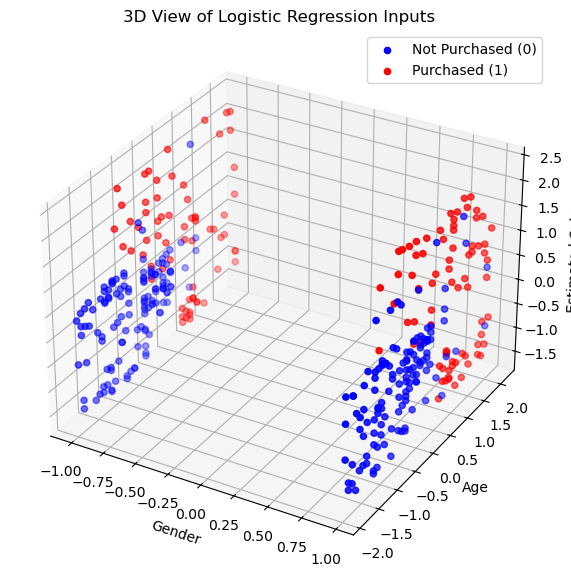

In [48]:
X = df[['Gender', 'Age', 'EstimatedSalary']].values
X = StandardScaler().fit_transform(X)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[y == 0, 0], X[y == 0, 1], X[y == 0, 2], c='blue', label='Not Purchased (0)')
ax.scatter(X[y == 1, 0], X[y == 1, 1], X[y == 1, 2], c='red', label='Purchased (1)')
ax.set_xlabel('Gender')
ax.set_ylabel('Age')
ax.set_zlabel('Estimated Salary')
ax.set_title('3D View of Logistic Regression Inputs')
plt.legend()
plt.show()

In [69]:
X = df.iloc[:, [1,2]].values # Features: Gender, Age, EstimatedSalary
y = df.iloc[:, -1].values # Target: Purchased (0 or 1)

In [70]:
# we can normalise a column in the data to improve model
X[:,[1]] = StandardScaler().fit_transform(X[:,[1]])

In [71]:
#split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 1/3, random_state=0)

In [72]:
#construct model and fit to the training data
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [73]:
# output the accuracy score
print('Our Accuracy is %.2f' % model.score(X_test, y_test))

# output the number of mislabeled points
print('Number of mislabeled points out of a total %d points : %d'
% (X_test.shape[0], (y_test != model.predict(X_test)).sum()))

Our Accuracy is 0.87
Number of mislabeled points out of a total 134 points : 17
